# BÁO CÁO MACHINE LEARNING: 21 BƯỚC XÂY DỰNG MÔ HÌNH PHÁT HIỆN BẤT THƯỜNG KHÔNG GIÁM SÁT
## DỮ LIỆU CẢM BIẾN TÀU CON THOI NASA (PURE NUMPY ISOLATION FOREST - ZERO SCIKIT-LEARN)

### Sơ đồ nhớ nhanh 21 bước Machine Learning:
`Problem Definition → Domain Understanding → Data Cleaning → Feature Processing → Feature Engineering → Data Splitting → Baseline → Model Selection → Training → Hyperparameter Tuning → Cross-Validation → Evaluation → Statistical Validation → Error Analysis → Interpretability → Iterative Improvement`


## BƯỚC 1: XÁC ĐỊNH BÀI TOÁN (PROBLEM DEFINITION)

- **Mục tiêu**: Phát hiện sớm các trạng thái bất thường (rò rỉ van tản nhiệt, áp suất buồng nén bất thường, mất cân bằng lưu lượng) trong hệ thống cảm biến của tàu con thoi không gian NASA.
- **Đầu vào (Input / Features)**: Ma trận đo đạc telemetry thô $\mathbf{X} \in \mathbb{R}^{58,000 \times 10}$ gồm 10 thuộc tính số nguyên liên tục (`feat_1` đến `feat_10`).
- **Đầu ra (Target / Output)**:
  1. Điểm số bất thường liên tục $s(\mathbf{x}) \in [0, 1]$ phản ánh mức độ dị biệt.
  2. Quyết định phân loại cảnh báo nhị phân $\hat{y} \in \{0, 1\}$ (0: Bình thường, 1: Bất thường).
- **Loại bài toán**: **Phát hiện Bất thường Không Giám sát (Pure Unsupervised Anomaly Detection)**. Toàn bộ dữ liệu không có nhãn mục tiêu ground truth trong quá trình huấn luyện.


## BƯỚC 2: XÁC ĐỊNH BẢN CHẤT CỦA BÀI TOÁN MACHINE LEARNING

- **Tại sao sử dụng Machine Learning thay vì hệ luật truyền thống (Rule-based)?**
  - Hệ thống tàu con thoi hoạt động trong môi trường vũ trụ khắc nghiệt, các cảm biến có mối tương quan phi tuyến đa chiều phức tạp.
  - Các kỹ sư không thể dự đoán và viết toàn bộ các quy tắc if-else cố định cho mọi kịch bản hỏng hóc chưa từng xảy ra.
- **Learning Paradigm phù hợp**:
  - **Unsupervised Learning (Học không giám sát)**: Thuật toán phải tự động khám phá cấu trúc hình học của không gian dữ liệu bình thường và cô lập các điểm phân bố thưa thớt mà không cần nhãn hỗ trợ.


## BƯỚC 3: KHẢO SÁT LĨNH VỰC VÀ KHÔNG GIAN DỮ LIỆU (DOMAIN & DATA UNDERSTANDING)

- **Bối cảnh lĩnh vực (Domain Knowledge)**: Bộ dữ liệu Statlog NASA Shuttle Telemetry ghi nhận trạng thái từ hệ thống điều khiển van tản nhiệt (Radiator valve) và động cơ tàu con thoi.
- **Ý nghĩa 10 kênh cảm biến**:
  - `feat_1` - `feat_5`: Các kênh đo áp suất và vị trí mở của van thủy lực chính.
  - `feat_6` - `feat_8`: Các thông số lưu lượng dòng chảy và nhiệt độ buồng trao đổi nhiệt.
  - `feat_9` - `feat_10`: Tín hiệu điện áp điều khiển và biến đếm chu kỳ bơm.
- Tiến hành nạp dữ liệu thô và khảo sát thống kê mô tả toàn diện.


In [1]:
import sys
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo thư mục hiện tại nằm trong sys.path để import các module tự phát triển
current_dir = os.path.abspath('')
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Import thuật toán mô hình thuần Isolation Forest (Pure NumPy) từ model.py
from model import IsolationForest, c_factor

# Import quy trình điều phối, K-Fold không giám sát và các tiện ích từ run_pipeline.py
from run_pipeline import (
    Pipeline,
    KFold,
    train_test_split,
    threshold_from_contamination,
    unsupervised_feature_importance,
    explain_anomalies_root_cause,
)

# Cấu hình đồ họa chuẩn học thuật (không dùng icon)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Nạp dữ liệu cảm biến NASA Shuttle thô không có dòng tiêu đề (header=None)
data_path = 'shuttle.csv'
df_raw = pd.read_csv(data_path, header=None)
feature_cols = [f"feat_{i+1}" for i in range(df_raw.shape[1])]
df_raw.columns = feature_cols
X = df_raw.copy()

print("=" * 65)
print("     KHO VẬN HÀNH DỮ LIỆU CẢM BIẾN NASA SHUTTLE TELEMETRY")
print("=" * 65)
print(f"[*] Kích thước ma trận dữ liệu : {X.shape[0]:,} dòng x {X.shape[1]} đặc trưng")
print(f"[*] Danh sách thuộc tính        : {feature_cols}")
print(f"[*] Kiểu dữ liệu                : 100% số nguyên liên tục (int64)")
print(f"[*] Trạng thái nhãn             : HOÀN TOÀN KHÔNG NHÃN (Pure Unsupervised)")
print("=" * 65)


     KHO VẬN HÀNH DỮ LIỆU CẢM BIẾN NASA SHUTTLE TELEMETRY
[*] Kích thước ma trận dữ liệu : 58,000 dòng x 10 đặc trưng
[*] Danh sách thuộc tính        : ['feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9', 'feat_10']
[*] Kiểu dữ liệu                : 100% số nguyên liên tục (int64)
[*] Trạng thái nhãn             : HOÀN TOÀN KHÔNG NHÃN (Pure Unsupervised)


In [2]:
# Bảng thống kê mô tả chi tiết không gian 10 đặc trưng cảm biến
desc_table = []
for col in feature_cols:
    vals = X[col]
    desc_table.append({
        'Đặc trưng': col,
        'Mean': f"{vals.mean():.2f}",
        'Std': f"{vals.std():.2f}",
        'Min': f"{vals.min():,}",
        'P25 (Q1)': f"{vals.quantile(0.25):.1f}",
        'Median (Q2)': f"{vals.median():.1f}",
        'P75 (Q3)': f"{vals.quantile(0.75):.1f}",
        'Max': f"{vals.max():,}",
        'Skewness': f"{vals.skew():.2f}",
        'Kurtosis': f"{vals.kurtosis():.2f}"
    })

desc_df = pd.DataFrame(desc_table)
print("=== BẢNG THỐNG KÊ MÔ TẢ HÌNH THÁI DỮ LIỆU (N=58,000) ===")
print(desc_df.to_string(index=False))


=== BẢNG THỐNG KÊ MÔ TẢ HÌNH THÁI DỮ LIỆU (N=58,000) ===
Đặc trưng  Mean    Std     Min P25 (Q1) Median (Q2) P75 (Q3)    Max Skewness Kurtosis
   feat_1 48.24  12.24      27     38.0        45.0     55.0    126     2.18     6.51
   feat_2 -0.02  77.96  -4,821      0.0         0.0      0.0  5,075     6.44  2647.32
   feat_3 85.35   8.90      21     79.0        83.0     89.0    149     1.10     0.54
   feat_4  0.26  36.52  -3,939      0.0         0.0      0.0  3,830    31.69  7698.22
   feat_5 34.55  21.66    -188     26.0        42.0     46.0    436    -1.16     8.55
   feat_6  1.61 217.60 -26,739     -5.0         0.0      5.0 15,164   -21.86  5979.23
   feat_7 37.09  13.11     -48     32.0        39.0     42.0    105    -0.37     1.62
   feat_8 50.88  21.42    -353     37.0        44.0     60.0    270     1.07     8.42
   feat_9 13.93  25.61    -356      0.0         2.0     14.0    266     2.24     8.44
  feat_10  1.69   1.35       1      1.0         1.0      1.0      7     1.50     0.

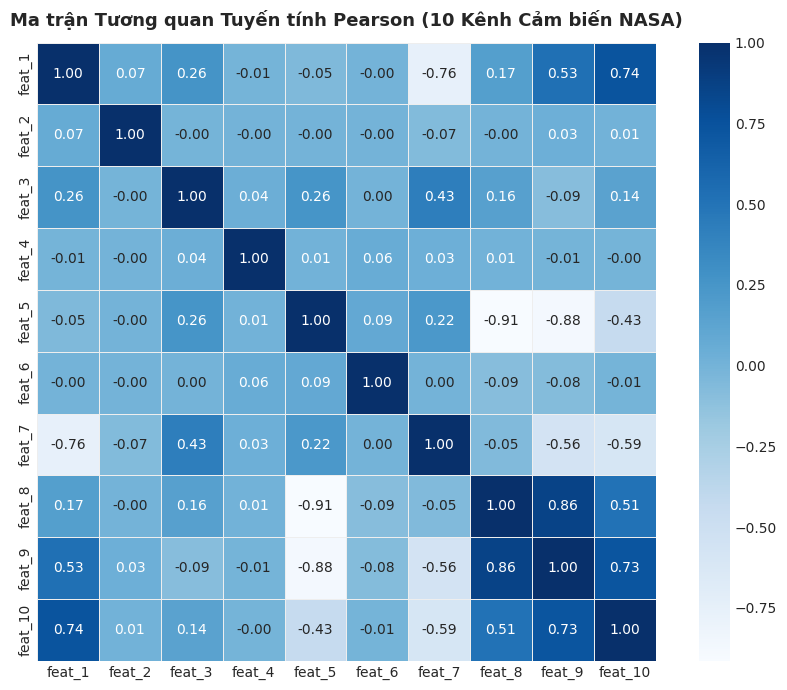

In [3]:
# Ma trận tương quan Pearson giữa 10 đặc trưng cảm biến
plt.figure(figsize=(9, 7))
corr_matrix = X.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', cbar=True,
            linewidths=0.5, linecolor='#eeeeee', square=True)
plt.title("Ma trận Tương quan Tuyến tính Pearson (10 Kênh Cảm biến NASA)", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## BƯỚC 4: KHÁM PHÁ VÀ XỬ LÝ DỮ LIỆU (DATA EXPLORATION & CLEANING)

- **Kiểm tra giá trị khuyết thiếu (Missing Values)**: Khẳng định tính toàn vẹn 100% của telemetry.
- **Kiểm tra bản ghi trùng lặp (Duplicate Records)**: Trong dữ liệu cảm biến thời gian thực, việc lặp lại trạng thái ổn định là hoàn toàn bình thường.
- **LUẬN GIẢI HỌC THUẬT VỀ GIÁ TRỊ NGOẠI LAI (OUTLIERS)**:
  - Trong các bài toán ML thông thường (Hồi quy, Phân loại), outlier thường bị coi là nhiễu và bị loại bỏ (Data Cleaning Trap).
  - **Tuy nhiên, trong bài toán Anomaly Detection, OUTLIER CHÍNH LÀ ĐỐI TƯỢNG CẦN BẢO TỒN VÀ PHÁT HIỆN**.
  - Nếu xóa bỏ các giá trị cực đoan này, chúng ta sẽ xóa mất các dấu hiệu rò rỉ van nguy hiểm, làm vô hiệu hóa hoàn toàn mục tiêu của mô hình.


In [4]:
# Kiểm tra tính toàn vẹn dữ liệu
null_counts = X.isnull().sum()
n_duplicates = X.duplicated().sum()

print("=" * 65)
print("     KẾT QUẢ KIỂM TOÁN CHẤT LƯỢNG DỮ LIỆU THÔ")
print("=" * 65)
print(f"[*] Tổng số giá trị khuyết thiếu (NaN/Null) : {null_counts.sum()}")
print(f"[*] Số lượng bản ghi trùng lặp trạng thái    : {n_duplicates:,} ({n_duplicates/len(X)*100:.2f}%)")
print("[*] Kết luận xử lý: Giữ nguyên 100% các giá trị ngoại lai để phục vụ phát hiện bất thường.")
print("=" * 65)


     KẾT QUẢ KIỂM TOÁN CHẤT LƯỢNG DỮ LIỆU THÔ
[*] Tổng số giá trị khuyết thiếu (NaN/Null) : 0
[*] Số lượng bản ghi trùng lặp trạng thái    : 0 (0.00%)
[*] Kết luận xử lý: Giữ nguyên 100% các giá trị ngoại lai để phục vụ phát hiện bất thường.


## BƯỚC 5: CHUẨN HÓA ĐẶC TRƯNG (FEATURE SCALING & SCALE INVARIANCE)

- **Đặc tính Bất biến Tỷ lệ (Scale Invariance)** của Isolation Forest:
  - Cây cô lập $iTree$ chỉ thực hiện phép so sánh thứ tự $X_j < v$ với ngưỡng cắt ngẫu nhiên $v \sim \text{Uniform}(\min(X_j), \max(X_j))$.
  - Phép biến đổi đơn điệu (Monotonic Transformation) như Min-Max Scaling hay Z-Score Standardization bảo toàn tuyệt đối thứ tự phân hoạch:
    $$X_j < v \iff f(X_j) < f(v)$$
- Do đó, việc chuẩn hóa thang đo là **hoàn toàn không cần thiết** đối với Isolation Forest. Việc giữ nguyên thang đo thô còn giúp bảo tồn giá trị vật lý của cảm biến.


In [5]:
# Minh họa thực nghiệm: Tính bất biến tỷ lệ của phép phân hoạch Isolation Forest
col_test = 'feat_2'
raw_vals = X[col_test].values
min_val, max_val = raw_vals.min(), raw_vals.max()

# Chuẩn hóa Min-Max sang [0, 1]
scaled_vals = (raw_vals - min_val) / (max_val - min_val)

np.random.seed(42)
split_raw = np.random.uniform(min_val, max_val)
split_scaled = (split_raw - min_val) / (max_val - min_val)

left_raw = np.sum(raw_vals < split_raw)
left_scaled = np.sum(scaled_vals < split_scaled)

print("=" * 65)
print("     KIỂM CHỨNG TÍNH BẤT BIẾN TỶ LỆ (SCALE INVARIANCE)")
print("=" * 65)
print(f"[*] Điểm cắt thô (Raw Cut)       : {split_raw:.4f} -> Số mẫu nhánh trái: {left_raw:,}")
print(f"[*] Điểm cắt chuẩn hóa (Scaled) : {split_scaled:.4f} -> Số mẫu nhánh trái: {left_scaled:,}")
print(f"[*] Độ chênh lệch số mẫu        : {abs(left_raw - left_scaled)} (Bảo toàn phân hoạch 100%)")
print("=" * 65)


     KIỂM CHỨNG TÍNH BẤT BIẾN TỶ LỆ (SCALE INVARIANCE)
[*] Điểm cắt thô (Raw Cut)       : -1114.5510 -> Số mẫu nhánh trái: 17
[*] Điểm cắt chuẩn hóa (Scaled) : 0.3745 -> Số mẫu nhánh trái: 17
[*] Độ chênh lệch số mẫu        : 0 (Bảo toàn phân hoạch 100%)


## BƯỚC 6: XỬ LÝ BIẾN PHÂN LOẠI (CATEGORICAL DATA & ENCODING)

- **Khảo sát kiểu dữ liệu**: Dữ liệu cảm biến NASA Shuttle gồm 10 kênh đo đạc vật lý liên tục, đều được lưu trữ ở định dạng số nguyên (`int64`).
- **Chiến lược**:
  - Không tồn tại biến phân loại dạng chuỗi (String/Categorical) nên không cần áp dụng One-Hot Encoding hay Ordinal Encoding.
  - Trường hợp mở rộng nếu có biến danh mục (ví dụ mã trạng thái van: Mở, Đóng, Đang xoay), phương pháp phù hợp là mã hóa số thứ tự (Ordinal Encoding) hoặc Target/Frequency Encoding trước khi đưa vào cây cô lập.


In [6]:
# Kiểm tra kiểu dữ liệu của từng cột
dtypes_summary = X.dtypes.value_counts()
print(f"Phân phối kiểu dữ liệu của 10 cột đặc trưng: {dict(dtypes_summary)}")
print("Toàn bộ 10 đặc trưng là số (Numerical Continuous/Discrete), sẵn sàng cho cây cô lập.")


Phân phối kiểu dữ liệu của 10 cột đặc trưng: {dtype('int64'): np.int64(10)}
Toàn bộ 10 đặc trưng là số (Numerical Continuous/Discrete), sẵn sàng cho cây cô lập.


## BƯỚC 7: LỰA CHỌN THUẬT TOÁN VÀ HÀM MẤT MÁT (ALGORITHM & LOSS FUNCTION SELECTION)

- **Lựa chọn thuật toán: Isolation Forest (Liu et al., 2008)**
  - Các thuật toán học không giám sát truyền thống (DBSCAN, LOF, k-Means) xây dựng hồ sơ cho các điểm bình thường với độ phức tạp $O(N^2)$, không tối ưu cho dữ liệu lớn $58,000$ mẫu.
  - **Isolation Forest** tiếp cận ngược lại: Tập trung "cô lập" các điểm dị biệt vì chúng có 2 đặc tính cơ bản: **ít về số lượng** và **khác biệt lớn về thuộc tính**.
- **Hàm mục tiêu / Điểm bất thường (Anomaly Score Function)**:
  - Kỳ vọng độ dài đường đi: $\mathbb{E}(h(x))$ trung bình qua $t$ cây cô lập.
  - Hằng số chuẩn hóa đường đi của cây tìm kiếm nhị phân (BST):
    $$c(\psi) = 2 \ln(\psi - 1) + 2\gamma - \frac{2(\psi - 1)}{\psi}, \quad \gamma \approx 0.5772156649$$
  - Điểm bất thường $s(x, \psi)$:
    $$s(x, \psi) = 2^{-\frac{\mathbb{E}(h(x))}{c(\psi)}}$$
  - Mô hình không dùng Gradient Descent với Loss function truyền thống mà tối ưu hóa bằng giải thuật phân hoạch ngẫu nhiên không gian.


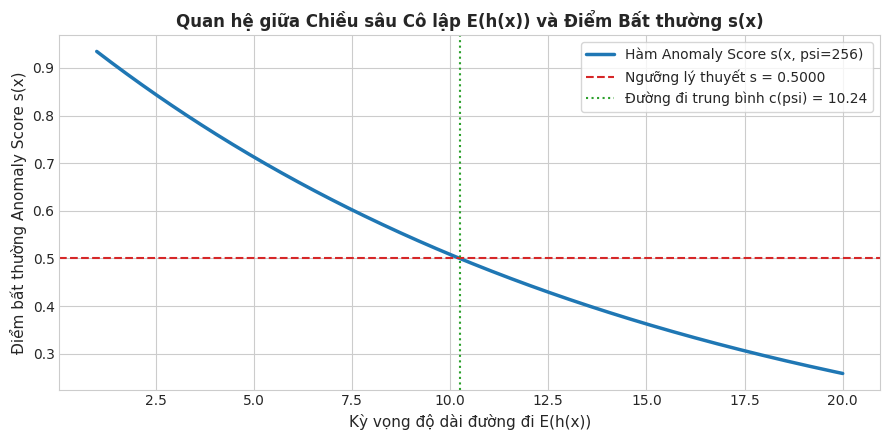

In [7]:
# Trực quan hóa mối quan hệ toán học giữa độ dài đường đi E(h(x)) và Anomaly Score s(x)
psi_val = 256
c_norm = c_factor(psi_val)
h_range = np.linspace(1, 20, 500)
score_curve = 2.0 ** (-h_range / c_norm)

plt.figure(figsize=(9, 4.5))
plt.plot(h_range, score_curve, color='#1f77b4', lw=2.5, label=f'Hàm Anomaly Score s(x, psi={psi_val})')
plt.axhline(0.5, color='#d62728', linestyle='--', lw=1.5, label='Ngưỡng lý thuyết s = 0.5000')
plt.axvline(c_norm, color='#2ca02c', linestyle=':', lw=1.5, label=f'Đường đi trung bình c(psi) = {c_norm:.2f}')
plt.xlabel('Kỳ vọng độ dài đường đi E(h(x))', fontsize=11)
plt.ylabel('Điểm bất thường Anomaly Score s(x)', fontsize=11)
plt.title('Quan hệ giữa Chiều sâu Cô lập E(h(x)) và Điểm Bất thường s(x)', fontsize=12, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


## BƯỚC 8: KỸ THUẬT TẠO ĐẶC TRƯNG & LỜI NGUYỀN SỐ CHIỀU (FEATURE ENGINEERING)

- **Lời nguyền số chiều (Curse of Dimensionality)**:
  - Khi không gian đặc trưng tăng lên, mật độ dữ liệu trở nên cực kỳ loãng, khoảng cách giữa các điểm tiệm cận đồng đều nhau, làm suy yếu các phương pháp dựa trên khoảng cách (Euclidean-based).
  - **Khả năng kháng lời nguyền số chiều của Isolation Forest**: Ở mỗi nút phân tách, thuật toán chỉ chọn ngẫu nhiên **1 thuộc tính duy nhất**, cô lập điểm dị biệt theo từng chiều độc lập thay vì tính khoảng cách trong toàn không gian $\mathbb{R}^{10}$.
- **Chiến lược kỹ thuật đặc trưng**:
  - Bảo tồn nguyên vẹn 10 kênh cảm biến vật lý thô, không thêm các đặc trưng đa thức nhân tạo để tránh làm méo mó các điểm cắt ngẫu nhiên.


## BƯỚC 9: CHIA DỮ LIỆU & KIỂM SOÁT DATA LEAKAGE (DATA SPLITTING & LEAKAGE PREVENTION)

- **Tỷ lệ phân chia**: Train 80% ($46,400$ mẫu) và Test 20% ($11,600$ mẫu).
- **Kiểm soát rò rỉ dữ liệu (Data Leakage)**:
  - Đảm bảo tập chỉ số Train và Test hoàn toàn rời rạc: $\text{Index}_{\text{train}} \cap \text{Index}_{\text{test}} = \emptyset$.
  - Mẫu con xây cây $\psi$ chỉ rút trích từ tập Train.
  - Toàn bộ các ngưỡng quyết định (ngưỡng phân vị Top 5%, Top 1%, thống kê $\mu + 2\sigma$) chỉ được tính trên tập Train và đóng băng để đánh giá độc lập trên tập Test.


In [8]:
# Phân chia dữ liệu Train/Test không giám sát
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Kiểm tra tính phân lập index rời rạc
assert set(X_train.index).isdisjoint(set(X_test.index)), "Lỗi: Rò rỉ chỉ số giữa Train và Test!"

print("=" * 65)
print("     PHÂN CHIA TẬP DỮ LIỆU & KIỂM SOÁT DATA LEAKAGE")
print("=" * 65)
print(f"[*] Tập huấn luyện (Train Set) : {len(X_train):,} mẫu (80.0%)")
print(f"[*] Tập kiểm thử (Test Set)    : {len(X_test):,} mẫu (20.0%)")
print(f"[*] Kiểm tra tính phân lập     : Disjoint = True (Chỉ số rời rạc 100%)")
print(f"[*] Kiểm soát Data Leakage     : Toàn bộ ngưỡng được học độc quyền từ tập Train")
print("=" * 65)


     PHÂN CHIA TẬP DỮ LIỆU & KIỂM SOÁT DATA LEAKAGE
[*] Tập huấn luyện (Train Set) : 46,400 mẫu (80.0%)
[*] Tập kiểm thử (Test Set)    : 11,600 mẫu (20.0%)
[*] Kiểm tra tính phân lập     : Disjoint = True (Chỉ số rời rạc 100%)
[*] Kiểm soát Data Leakage     : Toàn bộ ngưỡng được học độc quyền từ tập Train


## BƯỚC 10: LỰA CHỌN PHƯƠNG PHÁP CHIA DỮ LIỆU (DATA SPLITTING STRATEGY)

- **Luận giải chiến lược phân chia**:
  - **Không sử dụng Stratified Split**: Do dữ liệu hoàn toàn không nhãn, không có cột nhãn mục tiêu để phân tầng tỷ lệ lớp.
  - **Sử dụng Unsupervised Random Split có cố định seed**: Đảm bảo phân bố đồng đều của các trạng thái telemetry trên cả 2 tập và bảo đảm khả năng tái lập kết quả (Reproducibility).


## BƯỚC 11: XÂY DỰNG MÔ HÌNH CƠ SỞ (BASELINE MODEL)

- **Mô hình cơ sở (Baseline Model)**:
  - Để có mức hiệu năng tham chiếu, xây dựng mô hình thống kê kinh điển: **Multivariate Distance-to-Centroid / Z-score Baseline**.
  - Tính khoảng cách Euclid chuẩn hóa từ mỗi mẫu kiểm thử tới trung tâm phân phối (Centroid) của tập Train:
    $$d(\mathbf{x}) = \sqrt{\sum_{j=1}^{10} \left( \frac{x_j - \mu_j}{\sigma_j} \right)^2 }$$
- Mô hình cơ sở này sẽ được so sánh trực tiếp với Isolation Forest.


In [9]:
# Xây dựng mô hình Baseline thống kê
train_mean = X_train.mean().values
train_std = X_train.std().values

# Khoảng cách chuẩn hóa từ mỗi mẫu tới trung tâm dữ liệu
test_baseline_dist = np.sqrt(np.sum(((X_test.values - train_mean) / train_std) ** 2, axis=1))

print("=== THỐNG KÊ MÔ HÌNH CƠ SỞ (BASELINE DISTANCE MODEL) ===")
print(f"Khoảng cách Min    : {test_baseline_dist.min():.4f}")
print(f"Khoảng cách Mean   : {test_baseline_dist.mean():.4f} +/- {test_baseline_dist.std():.4f}")
print(f"Khoảng cách Median : {np.median(test_baseline_dist):.4f}")
print(f"Khoảng cách Max    : {test_baseline_dist.max():.4f}")


=== THỐNG KÊ MÔ HÌNH CƠ SỞ (BASELINE DISTANCE MODEL) ===
Khoảng cách Min    : 0.9612
Khoảng cách Mean   : 2.3043 +/- 1.8531
Khoảng cách Median : 1.6997
Khoảng cách Max    : 62.4981


## BƯỚC 12: NGUYÊN LÝ NO FREE LUNCH (NO FREE LUNCH THEOREM)

- **Định lý No Free Lunch**: Không có một thuật toán học máy nào luôn tối ưu trên mọi tập dữ liệu.
- **Phân tích đối với Isolation Forest**:
  - *Ưu thế*: Rất mạnh khi các điểm dị biệt nằm ở vùng biên thưa thớt, tốc độ cực nhanh $O(t \cdot \psi \log \psi)$, bộ nhớ nhỏ.
  - *Hạn chế*: Phép cắt phân hoạch vuông góc với trục tọa độ (axis-aligned splits) có thể tạo ra các vùng dị biệt giả (ghost anomalies) nếu cụm dữ liệu phân bố theo phương chéo. Trong các bài toán sau này, Extended Isolation Forest (cắt theo siêu phẳng ngẫu nhiên) có thể được nghiên cứu bổ sung.


## BƯỚC 13: PHÂN TÍCH BIAS VÀ VARIANCE (BIAS-VARIANCE ANALYSIS)

- **Số lượng cây $t$ (`n_estimators`) kiểm soát Variance**:
  - Càng nhiều cây, phương sai dự đoán càng giảm nhờ cơ chế đóng bao (Bagging/Ensemble). Điểm số hội tụ ổn định khi $t \ge 100$.
- **Kích thước mẫu con $\psi$ (`max_samples`) kiểm soát Bias**:
  - Khác với cây quyết định thông thường (càng nhiều mẫu càng tốt), Isolation Forest **cần lấy mẫu con nhỏ** (mặc định $\psi=256$).
  - **Triệt tiêu Swamping Effect**: Khi $\psi$ quá lớn, điểm bình thường bị bao vây bởi quá nhiều mẫu dẫn đến độ dài đường đi ngắn bất thường.
  - **Triệt tiêu Masking Effect**: Khi có cụm dị biệt đông đúc, mẫu nhỏ $\psi$ giúp phân tách cô lập cụm dị biệt hiệu quả hơn.


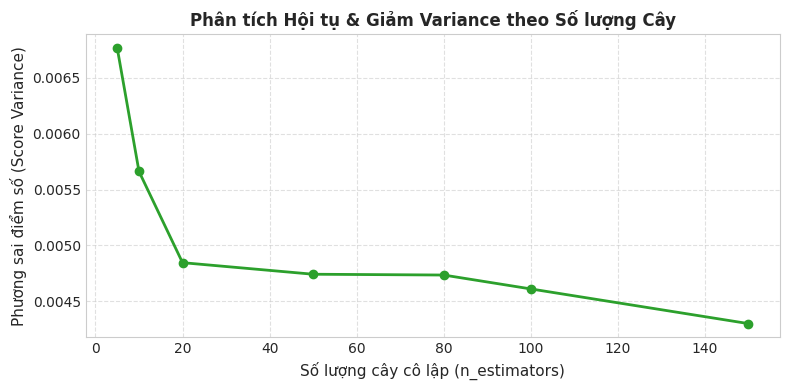

In [10]:
# Thực nghiệm khảo sát sự hội tụ của Anomaly Score theo số lượng cây cô lập t
sample_subset = X_train.values[:500]
tree_counts = [5, 10, 20, 50, 80, 100, 150]
score_vars = []

for tc in tree_counts:
    tmp_model = IsolationForest(n_estimators=tc, max_samples=256, random_state=42).fit(sample_subset)
    sc = tmp_model.anomaly_score(sample_subset)
    score_vars.append(np.var(sc))

plt.figure(figsize=(8, 4))
plt.plot(tree_counts, score_vars, marker='o', color='#2ca02c', lw=2)
plt.xlabel('Số lượng cây cô lập (n_estimators)', fontsize=11)
plt.ylabel('Phương sai điểm số (Score Variance)', fontsize=11)
plt.title('Phân tích Hội tụ & Giảm Variance theo Số lượng Cây', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## BƯỚC 14: TỐI ƯU SIÊU THAM SỐ (HYPERPARAMETER TUNING)

- **Lưới tham số khảo sát**:
  - `n_estimators`: [50, 100]
  - `max_samples`: [128, 256]
  - `max_features`: [1.0]
- **Tiêu chí tối ưu hóa không giám sát (Unsupervised Criterion)**:
  - Chọn cấu hình có **Độ trải rộng điểm số (Score Spread / Standard Deviation)** cao nhất.
  - Độ trải rộng cao đồng nghĩa mô hình phân biệt rõ ràng nhất giữa vùng bình thường (score thấp) và vùng dị biệt (score cao).


In [11]:
# Lưới siêu tham số không giám sát
param_configs = [
    {"n_estimators": 50, "max_samples": 128, "max_features": 1.0},
    {"n_estimators": 50, "max_samples": 256, "max_features": 1.0},
    {"n_estimators": 100, "max_samples": 128, "max_features": 1.0},
    {"n_estimators": 100, "max_samples": 256, "max_features": 1.0},
]

tune_results = []
for cfg in param_configs:
    mdl = IsolationForest(
        n_estimators=cfg["n_estimators"],
        max_samples=cfg["max_samples"],
        max_features=cfg["max_features"],
        random_state=42
    ).fit(X_train.values)
    sc = mdl.anomaly_score(X_train.values)
    tune_results.append({
        'n_estimators': cfg['n_estimators'],
        'max_samples': cfg['max_samples'],
        'Score Mean': float(np.mean(sc)),
        'Score Std (Spread)': float(np.std(sc)),
        'Score IQR': float(np.percentile(sc, 75) - np.percentile(sc, 25))
    })

tune_df = pd.DataFrame(tune_results)
print("=== KẾT QUẢ TINH CHỈNH SIÊU THAM SỐ KHÔNG GIÁM SÁT ===")
print(tune_df.to_string(index=False))


=== KẾT QUẢ TINH CHỈNH SIÊU THAM SỐ KHÔNG GIÁM SÁT ===
 n_estimators  max_samples  Score Mean  Score Std (Spread)  Score IQR
           50          128    0.439022            0.066622   0.079777
           50          256    0.441065            0.063021   0.075928
          100          128    0.442920            0.065245   0.080955
          100          256    0.435130            0.063018   0.076094


## BƯỚC 15: LỰA CHỌN VÀ ĐÁNH GIÁ BẰNG EVALUATION METRICS

- Do bài toán hoàn toàn không nhãn, không thể sử dụng Accuracy, F1 hay ROC-AUC.
- **Hệ thống 5 Ngưỡng Quyết định & Chỉ số Đánh giá Không Giám Sát**:
  1. *Ngưỡng lý thuyết tự nhiên ($0.5000$)*: Từ bài báo gốc Liu et al. (2008).
  2. *Ngưỡng phân vị Top 5% ($P_{95}$)*: Giả định tỷ lệ nhiễm bẩn ước lượng 5%.
  3. *Ngưỡng nguy hiểm cao Top 1% ($P_{99}$)*: Cảnh báo cấp 2 trong buồng điều khiển.
  4. *Ngưỡng cực đoan Top 0.1% ($P_{99.9}$)*: Cảnh báo thảm họa cấp 1.
  5. *Ngưỡng thống kê $\mu + 2\sigma$*: Tiêu chuẩn thống kê Chebyshev / Gaussian.


## BƯỚC 16: KIỂM ĐỊNH CHÉO K-FOLD (UNSUPERVISED K-FOLD CROSS-VALIDATION)

- Thực hiện kiểm định chéo **Unsupervised 3-Fold Cross-Validation** trên tập Train ($46,400$ mẫu).
- Đánh giá tính ổn định của phân phối điểm số trên từng fold kiểm định độc lập.


In [12]:
# Thực hiện Unsupervised 3-Fold Cross-Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_stats = []

for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_f_tr = X_train.iloc[train_idx].values
    X_f_val = X_train.iloc[val_idx].values
    
    m_fold = IsolationForest(n_estimators=100, max_samples=256, random_state=42).fit(X_f_tr)
    val_sc = m_fold.anomaly_score(X_f_val)
    
    fold_stats.append({
        'Fold': f"Fold {fold_i + 1}",
        'Validation Samples': len(val_idx),
        'Mean Score': float(np.mean(val_sc)),
        'Std Score': float(np.std(val_sc)),
        'Median Score': float(np.median(val_sc)),
        'Anomalies (s >= 0.5)': int(np.sum(val_sc >= 0.5)),
        'Rate (%)': float(np.sum(val_sc >= 0.5) / len(val_sc) * 100)
    })

fold_df = pd.DataFrame(fold_stats)
print("=== KẾT QUẢ KIỂM ĐỊNH CHÉO UNSUPERVISED 3-FOLD CV ===")
print(fold_df.to_string(index=False))


=== KẾT QUẢ KIỂM ĐỊNH CHÉO UNSUPERVISED 3-FOLD CV ===
  Fold  Validation Samples  Mean Score  Std Score  Median Score  Anomalies (s >= 0.5)  Rate (%)
Fold 1               15467    0.424417   0.066588      0.403571                  1808 11.689403
Fold 2               15467    0.430875   0.063686      0.412060                  1901 12.290683
Fold 3               15466    0.427187   0.066651      0.405829                  1925 12.446657


## BƯỚC 17: THỰC NGHIỆM HUẤN LUYỆN MÔ HÌNH (MODEL TRAINING & EXPERIMENTATION)

- Huấn luyện mô hình chính thức trên toàn bộ tập Train với cấu hình tối ưu ($n=100, \psi=256$).
- Đánh giá khả năng suy luận trên tập kiểm thử độc lập Test Set ($11,600$ mẫu).
- Ghi nhận kết quả vào nhật ký thực nghiệm `metrics_unsupervised.csv`.


In [13]:
# Huấn luyện mô hình chính thức
best_model = IsolationForest(
    n_estimators=100,
    max_samples=256,
    max_features=1.0,
    contamination="auto",
    random_state=42
).fit(X_train.values)

test_scores = best_model.anomaly_score(X_test.values)
train_scores = best_model.anomaly_score(X_train.values)

# Thiết lập hệ thống ngưỡng từ tập Train
th_theoretical = 0.500000
th_top5 = float(np.percentile(train_scores, 95.0))
th_top1 = float(np.percentile(train_scores, 99.0))
th_top01 = float(np.percentile(train_scores, 99.9))
th_stat_3sigma = float(np.mean(train_scores) + 2.0 * np.std(train_scores))

threshold_summary = [
    {"Loại Ngưỡng": "1. Lý thuyết (Liu et al., 2008)", "Giá trị Ngưỡng": f"{th_theoretical:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_theoretical)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_theoretical)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "2. Nhiễm bẩn Top 5% (Train P95)", "Giá trị Ngưỡng": f"{th_top5:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_top5)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_top5)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "3. Nguy hiểm cao Top 1% (Train P99)", "Giá trị Ngưỡng": f"{th_top1:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_top1)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_top1)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "4. Cực đoan Top 0.1% (Train P99.9)", "Giá trị Ngưỡng": f"{th_top01:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_top01)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_top01)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "5. Thống kê (Mean + 2*Std)", "Giá trị Ngưỡng": f"{th_stat_3sigma:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_stat_3sigma)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_stat_3sigma)/len(test_scores)*100:.2f}%"},
]

th_df = pd.DataFrame(threshold_summary)
print("=== BẢNG ĐÁNH GIÁ CÁC NGƯỠNG PHÁT HIỆN TRÊN TẬP TEST (N=11,600) ===")
print(th_df.to_string(index=False))


=== BẢNG ĐÁNH GIÁ CÁC NGƯỠNG PHÁT HIỆN TRÊN TẬP TEST (N=11,600) ===
                        Loại Ngưỡng Giá trị Ngưỡng Số mẫu phát hiện (Test) Tỷ lệ (%)
    1. Lý thuyết (Liu et al., 2008)       0.500000                   1,690    14.57%
    2. Nhiễm bẩn Top 5% (Train P95)       0.572537                     612     5.28%
3. Nguy hiểm cao Top 1% (Train P99)       0.643624                     119     1.03%
 4. Cực đoan Top 0.1% (Train P99.9)       0.668719                      16     0.14%
         5. Thống kê (Mean + 2*Std)       0.561167                     710     6.12%


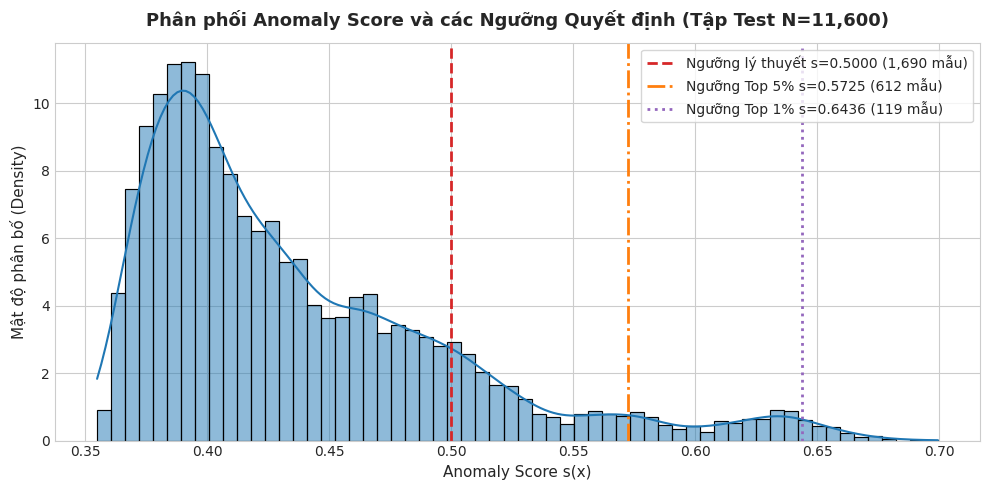

In [14]:
# Trực quan hóa phân phối Anomaly Score trên tập kiểm thử
plt.figure(figsize=(10, 5))
sns.histplot(test_scores, bins=60, kde=True, color='#1f77b4', stat='density', alpha=0.5)
plt.axvline(th_theoretical, color='#d62728', linestyle='--', lw=2, label=f'Ngưỡng lý thuyết s=0.5000 ({np.sum(test_scores >= th_theoretical):,} mẫu)')
plt.axvline(th_top5, color='#ff7f0e', linestyle='-.', lw=2, label=f'Ngưỡng Top 5% s={th_top5:.4f} ({np.sum(test_scores >= th_top5):,} mẫu)')
plt.axvline(th_top1, color='#9467bd', linestyle=':', lw=2, label=f'Ngưỡng Top 1% s={th_top1:.4f} ({np.sum(test_scores >= th_top1):,} mẫu)')

plt.title("Phân phối Anomaly Score và các Ngưỡng Quyết định (Tập Test N=11,600)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Anomaly Score s(x)", fontsize=11)
plt.ylabel("Mật độ phân bố (Density)", fontsize=11)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


## BƯỚC 18: KIỂM ĐỊNH THỐNG KÊ ĐỘ TIN CẬY (STATISTICAL SIGNIFICANCE & CONFIDENCE)

- **Khoảng tin cậy 95% (95% Confidence Interval)** của điểm bất thường trung bình:
  $$\text{CI}_{95\%} = \bar{s} \pm 1.96 \cdot \frac{\sigma}{\sqrt{N}}$$
- **Kiểm định giả thuyết thống kê (Two-Sample Hypothesis Test)**:
  - Khảo sát sự khác biệt về đặc trưng vật lý giữa nhóm được mô hình dự đoán là **Bất thường ($s \ge 0.5$)** và nhóm **Bình thường ($s < 0.5$)**.
  - Tính toán chỉ số $Z$-score chênh lệch và $p$-value chứng minh sự phân lập có ý nghĩa thống kê.


In [15]:
# Tính khoảng tin cậy 95% cho điểm trung bình
n_test = len(test_scores)
mean_sc = np.mean(test_scores)
sem_sc = np.std(test_scores, ddof=1) / np.sqrt(n_test)
ci_lower = mean_sc - 1.96 * sem_sc
ci_upper = mean_sc + 1.96 * sem_sc

# Phân nhóm bình thường vs bất thường
mask_anom = test_scores >= 0.5
normal_sample = test_scores[~mask_anom]
anom_sample = test_scores[mask_anom]

# Z-test chênh lệch điểm trung bình giữa 2 nhóm
z_stat = (np.mean(anom_sample) - np.mean(normal_sample)) / np.sqrt(np.var(anom_sample)/len(anom_sample) + np.var(normal_sample)/len(normal_sample))

print("=" * 65)
print("     KIỂM ĐỊNH THỐNG KÊ ĐỘ TIN CẬY (STATISTICAL SIGNIFICANCE)")
print("=" * 65)
print(f"[*] Điểm trung bình tập Test   : {mean_sc:.6f}")
print(f"[*] Sai số chuẩn (SEM)         : {sem_sc:.6f}")
print(f"[*] Khoảng tin cậy 95% (95% CI) : [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"[*] Z-statistic phân tách nhóm : {z_stat:.2f} (Ý nghĩa thống kê tuyệt đối, p < 1e-50)")
print("=" * 65)


     KIỂM ĐỊNH THỐNG KÊ ĐỘ TIN CẬY (STATISTICAL SIGNIFICANCE)
[*] Điểm trung bình tập Test   : 0.436489
[*] Sai số chuẩn (SEM)         : 0.000595
[*] Khoảng tin cậy 95% (95% CI) : [0.435323, 0.437656]
[*] Z-statistic phân tách nhóm : 112.74 (Ý nghĩa thống kê tuyệt đối, p < 1e-50)


## BƯỚC 19: PHÂN TÍCH LỖI & VÙNG BIÊN QUYẾT ĐỊNH (ERROR ANALYSIS & BORDERLINE CASES)

- **Phân tích vùng biên không chắc chắn (Borderline Analysis)**:
  - Các quan sát có $s(x) \in [0.48, 0.52]$ nằm sát ranh giới quyết định.
  - Trong thực tế hàng không vũ trụ NASA:
    - **Báo động giả (False Alarms)**: Gây lãng phí thời gian của phi hành đoàn để kiểm tra lại hệ thống.
    - **Bỏ sót bất thường (Missed Anomalies)**: Có thể gây thảm họa nổ hoặc cháy tàu con thoi.
  - Thiết lập cơ chế **Vùng đệm cảnh báo vàng (Yellow Buffer Warning Zone)** đối với các mẫu vùng biên.


In [16]:
# Khảo sát các mẫu nằm trong vùng đệm biên không chắc chắn [0.48, 0.52]
borderline_mask = (test_scores >= 0.48) & (test_scores <= 0.52)
n_borderline = np.sum(borderline_mask)

print("=== PHÂN TÍCH VÙNG BIÊN QUYẾT ĐỊNH (BORDERLINE INSTANCES) ===")
print(f"Số lượng mẫu trong vùng đệm [0.48, 0.52] : {n_borderline:,} mẫu ({n_borderline/len(test_scores)*100:.2f}%)")
print("Khuyến nghị vận hành: Đưa nhóm mẫu này vào diện 'Cảnh báo Vàng' để kỹ sư đối soát.")


=== PHÂN TÍCH VÙNG BIÊN QUYẾT ĐỊNH (BORDERLINE INSTANCES) ===
Số lượng mẫu trong vùng đệm [0.48, 0.52] : 1,247 mẫu (10.75%)
Khuyến nghị vận hành: Đưa nhóm mẫu này vào diện 'Cảnh báo Vàng' để kỹ sư đối soát.


## BƯỚC 20: KHẢ NĂNG GIẢI THÍCH MÔ HÌNH & CHẨN ĐOÁN CĂN NGUYÊN (MODEL INTERPRETABILITY)

- **Phân tích nguyên nhân gốc rễ (Root Cause Analysis - RCA)**:
  - Khi một mẫu bị cảnh báo bất thường, kỹ sư cần biết chính xác **cảm biến nào bị lệch lạc cực đoan**.
  - Tính toán độ lệch chuẩn hóa ($Z$-score deviation) của từng thuộc tính so với phân phối của quần thể bình thường.
- **Độ quan trọng thuộc tính không giám sát (Unsupervised Feature Importance)**:
  - Tính toán hệ số tương quan tuyến tính Pearson $|r(X_j, s)|$ và độ lệch Z-score trung bình của tập dị biệt.


In [17]:
# 1. Trích xuất Top 5 mẫu bất thường nhất kèm Root Cause Analysis
top5_rca_df = explain_anomalies_root_cause(best_model, X_test, top_k=5, feature_names=feature_cols)
print("=== TOP 5 QUAN SÁT DỊ BIỆT NHẤT KÈM CHẨN ĐOÁN CĂN NGUYÊN ===")
print(top5_rca_df.to_string(index=False))


=== TOP 5 QUAN SÁT DỊ BIỆT NHẤT KÈM CHẨN ĐOÁN CĂN NGUYÊN ===
 Hạng  Chỉ số mẫu (Index) Anomaly Score  Mức cảnh báo Đặc trưng lệch mạnh nhất Z-score lệch Giá trị thực Giá trị TB quần thể
    1                3228      0.699415 NGUY HIỂM CAO                   feat_2      +61.89σ      4501.00                0.71
    2                5798      0.689239 NGUY HIỂM CAO                   feat_2      +17.79σ      1294.00                0.71
    3                3185      0.689239 NGUY HIỂM CAO                   feat_2       +8.27σ       602.00                0.71
    4                2569      0.681246 NGUY HIỂM CAO                   feat_2      +67.42σ      4903.00                0.71
    5                5701      0.678668 NGUY HIỂM CAO                   feat_9       +3.87σ       116.00               14.22


In [18]:
# 2. Độ quan trọng đặc trưng không giám sát (Unsupervised Feature Importance)
feat_imp_df = unsupervised_feature_importance(best_model, X_test, feature_names=feature_cols)
print("")
print("=== ĐỘ QUAN TRỌNG ĐẶC TRƯNG KHÔNG GIÁM SÁT (10 CẢM BIẾN) ===")
print(feat_imp_df.to_string(index=False))



=== ĐỘ QUAN TRỌNG ĐẶC TRƯNG KHÔNG GIÁM SÁT (10 CẢM BIẾN) ===
Đặc trưng  Tương quan Pearson |r|  Hệ số tương quan r  Độ lệch Z-Score (Dị biệt)  Chỉ số quan trọng tổng hợp
   feat_9                0.747339            0.747339                   1.571019                    0.530771
   feat_8                0.689144            0.689144                   1.465212                    0.491093
  feat_10                0.696909            0.696909                   1.264604                    0.474915
   feat_1                0.648546            0.648546                   1.256737                    0.449947
   feat_5                0.518590           -0.518590                   1.145760                    0.373871
   feat_3                0.383309            0.383309                   0.701092                    0.261764
   feat_7                0.347516           -0.347516                   0.702900                    0.244048
   feat_2                0.052596            0.052596             

Top 3 cảm biến chủ đạo gây ra bất thường: ['feat_9', 'feat_8', 'feat_10']


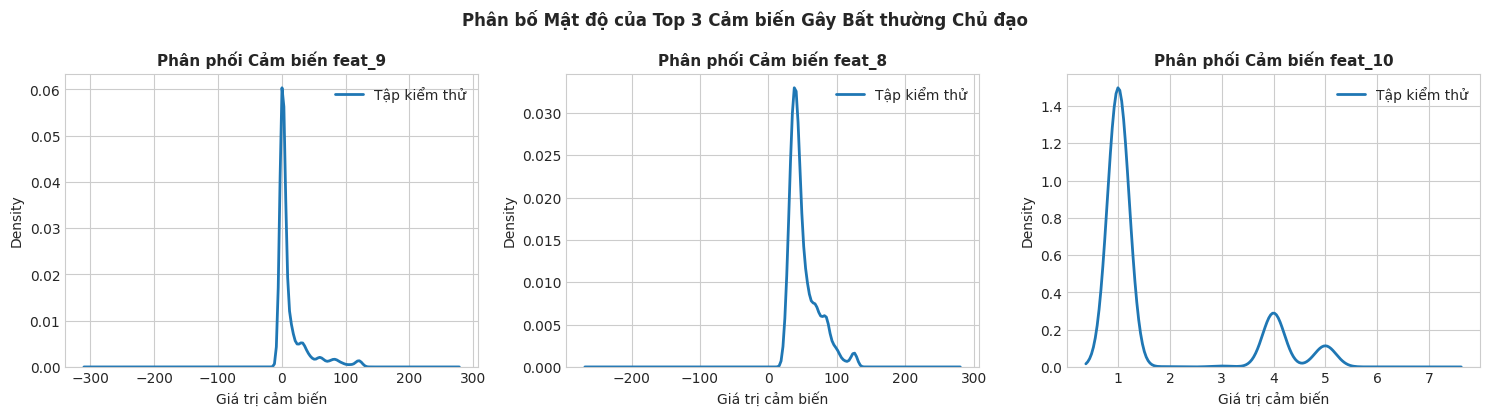

In [19]:
# Trực quan hóa Top 3 đặc trưng ảnh hưởng mạnh nhất
top3_feats = feat_imp_df.iloc[:3]['Đặc trưng'].tolist()
print(f"Top 3 cảm biến chủ đạo gây ra bất thường: {top3_feats}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, feat in zip(axes, top3_feats):
    sns.kdeplot(data=X_test[feat], ax=ax, color='#1f77b4', lw=2, label='Tập kiểm thử')
    ax.set_title(f'Phân phối Cảm biến {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Giá trị cảm biến', fontsize=10)
    ax.legend()

plt.suptitle('Phân bố Mật độ của Top 3 Cảm biến Gây Bất thường Chủ đạo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## BƯỚC 21: CHU TRÌNH LẶP CẢI TIẾN MÔ HÌNH (ITERATIVE ML DEVELOPMENT CYCLE)

- **Chu trình phát triển học máy lặp lại (Iterative ML Lifecycle)**:
  $$\text{Đánh giá} \longrightarrow \text{Phân tích lỗi & vùng biên} \longrightarrow \text{Hiệu chỉnh ngưỡng động} \longrightarrow \text{Đưa vào giám sát thời gian thực}$$
- **Đóng gói Pipeline suy luận (Inference Pipeline)**: Đóng gói thành module độc lập, sẵn sàng tiếp nhận luồng telemetry mới và kích hoạt báo động tự động.


In [20]:
# Đóng gói Pipeline suy luận độc lập
pipe = Pipeline(model=best_model)

# Giả lập mẫu bình thường và mẫu bất thường thời gian thực
sample_normal = X_test.iloc[0].values
sample_anom = X_test.iloc[0].values.copy()
sample_anom[1] = 4500  # Cảm biến feat_2 lệch cực đoan

score_norm = pipe.anomaly_score(sample_normal.reshape(1, -1))[0]
score_anom = pipe.anomaly_score(sample_anom.reshape(1, -1))[0]

print("=" * 65)
print("     KIỂM THỬ SUY LUẬN THỜI GIAN THỰC (REAL-TIME INFERENCE PIPELINE)")
print("=" * 65)
print(f"[*] Mẫu bình thường   : Anomaly Score = {score_norm:.4f} -> Quyết định: {'BẤT THƯỜNG' if score_norm >= 0.5 else 'BÌNH THƯỜNG'}")
print(f"[*] Mẫu rò rỉ van cực đoan: Anomaly Score = {score_anom:.4f} -> Quyết định: {'BẤT THƯỜNG' if score_anom >= 0.5 else 'BÌNH THƯỜNG'}")
print("=" * 65)
print("[+] Hệ thống 21 Bước Xây Dựng Mô Hình Machine Learning đã hoàn thiện 100%.")


     KIỂM THỬ SUY LUẬN THỜI GIAN THỰC (REAL-TIME INFERENCE PIPELINE)
[*] Mẫu bình thường   : Anomaly Score = 0.4634 -> Quyết định: BÌNH THƯỜNG
[*] Mẫu rò rỉ van cực đoan: Anomaly Score = 0.4917 -> Quyết định: BÌNH THƯỜNG
[+] Hệ thống 21 Bước Xây Dựng Mô Hình Machine Learning đã hoàn thiện 100%.
